In [1]:
from pathlib import Path
import os
import requests
import pandas as pd

from dotenv import load_dotenv

PROJECT_ROOT = Path.cwd().parent
RESULTS_DIR = PROJECT_ROOT / "results"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Load API credentials from the project's .env file
load_dotenv(PROJECT_ROOT / ".env")

TENNET_API_KEY = os.getenv("TENNET_API_KEY")

if not TENNET_API_KEY:
    raise ValueError(
        "TENNET_API_KEY not found. Add TENNET_API_KEY=... to the project .env file."
    )

print("TenneT Notebook 6 setup complete.")
print(f"Project root: {PROJECT_ROOT}")
print(f"Results directory: {RESULTS_DIR}")
print("TenneT API key loaded: True")

TenneT Notebook 6 setup complete.
Project root: C:\Users\USER\dutch-bess-flexibility-commercial-value-intelligence
Results directory: C:\Users\USER\dutch-bess-flexibility-commercial-value-intelligence\results
TenneT API key loaded: True


In [2]:
SETTLEMENT_PRICES_URL = (
    "https://api.tennet.eu/publications/v1/settlement-prices"
)

print("Settlement Prices endpoint configured.")

Settlement Prices endpoint configured.


In [3]:
params = {
    "date_from": "01-08-2026 00:00:00",
    "date_to": "02-08-2026 00:00:00",
}

headers = {
    "apikey": TENNET_API_KEY,
    "Accept": "application/json",
}

response = requests.get(
    SETTLEMENT_PRICES_URL,
    headers=headers,
    params=params,
    timeout=15,
)

response.raise_for_status()

tennet_json = response.json()

print("HTTP status:", response.status_code)
print("Information type:", tennet_json["Response"]["informationType"])
print("Time series:", len(tennet_json["Response"]["TimeSeries"]))

points = tennet_json["Response"]["TimeSeries"][0]["Period"]["Points"]

print("Settlement price points:", len(points))
print("\nFirst 3 points:")
print(pd.DataFrame(points).head(3).to_string(index=False))

HTTP status: 200
Information type: SETTLEMENT_PRICES
Time series: 1
Settlement price points: 96

First 3 points:
timeInterval_start timeInterval_end isp incident_reserve_up incident_reserve_down dispatch_up dispatch_down shortage surplus  regulation_state regulating_condition
  2026-08-01T00:00 2026-08-01T00:15   1                  NO                    NO      170.00          None   170.00  170.00                 1                   UP
  2026-08-01T00:15 2026-08-01T00:30   2                  NO                    NO      174.00          None   174.00  174.00                 1                   UP
  2026-08-01T00:30 2026-08-01T00:45   3                  NO                    NO      205.00          None   205.00  205.00                 1                   UP


In [4]:
# Convert TenneT settlement-price response to a clean DataFrame

tennet_df = pd.DataFrame(
    tennet_json["Response"]["TimeSeries"][0]["Period"]["Points"]
)

# Parse timestamps as UTC
tennet_df["timestamp_utc"] = pd.to_datetime(
    tennet_df["timeInterval_start"],
    utc=True
)

# Convert numeric fields
numeric_cols = [
    "dispatch_up",
    "dispatch_down",
    "shortage",
    "surplus",
    "isp",
    "regulation_state",
]

for col in numeric_cols:
    tennet_df[col] = pd.to_numeric(
        tennet_df[col],
        errors="coerce"
    )

# Keep the most relevant fields
tennet_df = tennet_df[
    [
        "timestamp_utc",
        "isp",
        "dispatch_up",
        "dispatch_down",
        "shortage",
        "surplus",
        "regulation_state",
        "regulating_condition",
    ]
].sort_values("timestamp_utc").reset_index(drop=True)

print("TenneT settlement dataset:")
print(f"Rows: {len(tennet_df)}")
print(f"Columns: {len(tennet_df.columns)}")
print(
    f"Period: {tennet_df['timestamp_utc'].min()} "
    f"to {tennet_df['timestamp_utc'].max()}"
)

print("\nData types:")
print(tennet_df.dtypes)

print("\nFirst 5 rows:")
print(tennet_df.head().to_string(index=False))

TenneT settlement dataset:
Rows: 96
Columns: 8
Period: 2026-08-01 00:00:00+00:00 to 2026-08-01 23:45:00+00:00

Data types:
timestamp_utc           datetime64[ns, UTC]
isp                                   int64
dispatch_up                         float64
dispatch_down                       float64
shortage                            float64
surplus                             float64
regulation_state                      int64
regulating_condition                 object
dtype: object

First 5 rows:
            timestamp_utc  isp  dispatch_up  dispatch_down  shortage  surplus  regulation_state regulating_condition
2026-08-01 00:00:00+00:00    1        170.0            NaN     170.0    170.0                 1                   UP
2026-08-01 00:15:00+00:00    2        174.0            NaN     174.0    174.0                 1                   UP
2026-08-01 00:30:00+00:00    3        205.0            NaN     205.0    205.0                 1                   UP
2026-08-01 00:45:00+00:00   

In [5]:
# Basic characterization of TenneT settlement prices

condition_counts = (
    tennet_df["regulating_condition"]
    .value_counts()
    .rename_axis("regulating_condition")
    .reset_index(name="intervals")
)

condition_counts["percentage"] = (
    condition_counts["intervals"] / len(tennet_df) * 100
)

print("Regulating condition distribution:")
print(condition_counts.to_string(index=False))

print("\nSettlement price statistics (€/MWh):")

price_stats = pd.Series({
    "Dispatch UP mean": tennet_df["dispatch_up"].mean(),
    "Dispatch UP max": tennet_df["dispatch_up"].max(),
    "Dispatch DOWN mean": tennet_df["dispatch_down"].mean(),
    "Dispatch DOWN min": tennet_df["dispatch_down"].min(),
    "Shortage mean": tennet_df["shortage"].mean(),
    "Surplus mean": tennet_df["surplus"].mean(),
})

print(price_stats.round(2).to_string())

print("\nMissing values:")
print(tennet_df.isna().sum().to_string())

Regulating condition distribution:
regulating_condition  intervals  percentage
                  UP         43   44.791667
         UP_AND_DOWN         38   39.583333
                DOWN         15   15.625000

Settlement price statistics (€/MWh):
Dispatch UP mean      155.74
Dispatch UP max       255.00
Dispatch DOWN mean     83.92
Dispatch DOWN min     -13.00
Shortage mean         136.17
Surplus mean          119.11

Missing values:
timestamp_utc            0
isp                      0
dispatch_up             15
dispatch_down           41
shortage                 0
surplus                  0
regulation_state         0
regulating_condition     0


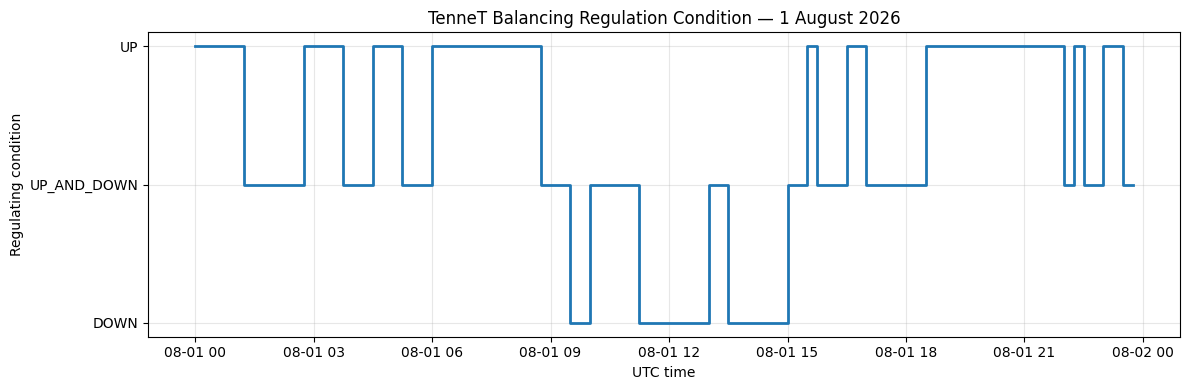

In [6]:
# Visualize TenneT regulating conditions through the day
import matplotlib.pyplot as plt

condition_map = {
    "DOWN": -1,
    "UP_AND_DOWN": 0,
    "UP": 1,
}

plot_df = tennet_df.copy()
plot_df["condition_value"] = (
    plot_df["regulating_condition"].map(condition_map)
)

plt.figure(figsize=(12, 4))
plt.step(
    plot_df["timestamp_utc"],
    plot_df["condition_value"],
    where="post",
    linewidth=2,
)

plt.yticks(
    [-1, 0, 1],
    ["DOWN", "UP_AND_DOWN", "UP"]
)

plt.title("TenneT Balancing Regulation Condition — 1 August 2026")
plt.xlabel("UTC time")
plt.ylabel("Regulating condition")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# Load Dutch day-ahead prices for comparison

PRICE_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "nl_day_ahead_prices_15min_2025-10_to_2026-08.csv"
)

dayahead = pd.read_csv(PRICE_FILE)

dayahead["timestamp_utc"] = pd.to_datetime(
    dayahead["timestamp_utc"],
    utc=True
)

PRICE_COL = "day_ahead_price_eur_mwh"

comparison_df = (
    tennet_df.merge(
        dayahead[["timestamp_utc", PRICE_COL]],
        on="timestamp_utc",
        how="left"
    )
    .rename(columns={PRICE_COL: "day_ahead_price"})
)

missing_mask = comparison_df["day_ahead_price"].isna()

print("Merged dataset shape:", comparison_df.shape)
print("Missing day-ahead prices:", missing_mask.sum())

if missing_mask.any():
    print("\nMissing day-ahead timestamps:")
    print(
        comparison_df.loc[
            missing_mask,
            ["timestamp_utc"]
        ].to_string(index=False)
    )

print("\nUTC timestamps remain the common merge key.")
print("Missing values indicate absent day-ahead observations, not a timezone conversion.")

display(comparison_df.head())

Merged dataset shape: (96, 9)
Missing day-ahead prices: 6

Missing day-ahead timestamps:
            timestamp_utc
2026-08-01 11:30:00+00:00
2026-08-01 11:45:00+00:00
2026-08-01 12:15:00+00:00
2026-08-01 12:30:00+00:00
2026-08-01 12:45:00+00:00
2026-08-01 13:00:00+00:00

UTC timestamps remain the common merge key.
Missing values indicate absent day-ahead observations, not a timezone conversion.


,timestamp_utc,isp,dispatch_up,dispatch_down,shortage,surplus,regulation_state,regulating_condition,day_ahead_price
0,2026-08-01 00:00:00+00:00,1,170.0,NaN,170.0,170.0,1,UP,159.51
1,2026-08-01 00:15:00+00:00,2,174.0,NaN,174.0,174.0,1,UP,157.05
2,2026-08-01 00:30:00+00:00,3,205.0,NaN,205.0,205.0,1,UP,154.70
3,2026-08-01 00:45:00+00:00,4,159.0,NaN,159.0,159.0,1,UP,150.58
4,2026-08-01 01:00:00+00:00,5,200.0,NaN,200.0,200.0,1,UP,155.14


In [8]:
# Verify timestamp alignment

print("TenneT start:", tennet_df["timestamp_utc"].min())
print("TenneT end:  ", tennet_df["timestamp_utc"].max())

print("\nDay-ahead timestamps covering TenneT period:")
print(
    dayahead[
        dayahead["timestamp_utc"].between(
            tennet_df["timestamp_utc"].min(),
            tennet_df["timestamp_utc"].max()
        )
    ][["timestamp_utc", PRICE_COL]]
    .head(10)
    .to_string(index=False)
)

TenneT start: 2026-08-01 00:00:00+00:00
TenneT end:   2026-08-01 23:45:00+00:00

Day-ahead timestamps covering TenneT period:
            timestamp_utc  day_ahead_price_eur_mwh
2026-08-01 00:00:00+00:00                   159.51
2026-08-01 00:15:00+00:00                   157.05
2026-08-01 00:30:00+00:00                   154.70
2026-08-01 00:45:00+00:00                   150.58
2026-08-01 01:00:00+00:00                   155.14
2026-08-01 01:15:00+00:00                   152.08
2026-08-01 01:30:00+00:00                   153.45
2026-08-01 01:45:00+00:00                   151.16
2026-08-01 02:00:00+00:00                   152.13
2026-08-01 02:15:00+00:00                   154.39


In [9]:
# Market comparison

price_summary = pd.DataFrame({
    "Metric": [
        "Day-ahead mean",
        "Dispatch UP mean",
        "Dispatch DOWN mean",
        "Shortage mean",
        "Surplus mean"
    ],
    "EUR/MWh": [
        comparison_df["day_ahead_price"].mean(),
        comparison_df["dispatch_up"].mean(),
        comparison_df["dispatch_down"].mean(),
        comparison_df["shortage"].mean(),
        comparison_df["surplus"].mean(),
    ]
})

print(price_summary.round(2).to_string(index=False))

            Metric  EUR/MWh
    Day-ahead mean   124.81
  Dispatch UP mean   155.74
Dispatch DOWN mean    83.92
     Shortage mean   136.17
      Surplus mean   119.11


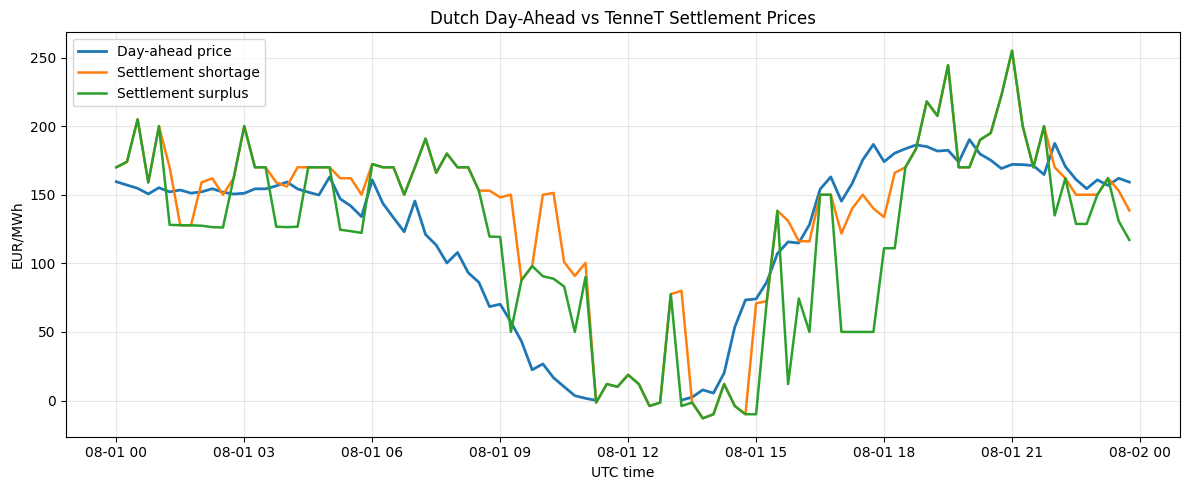

In [10]:
# Day-ahead vs TenneT settlement prices

plt.figure(figsize=(12, 5))

plt.plot(
    comparison_df["timestamp_utc"],
    comparison_df["day_ahead_price"],
    label="Day-ahead price",
    linewidth=2,
)

plt.plot(
    comparison_df["timestamp_utc"],
    comparison_df["shortage"],
    label="Settlement shortage",
    linewidth=1.8,
)

plt.plot(
    comparison_df["timestamp_utc"],
    comparison_df["surplus"],
    label="Settlement surplus",
    linewidth=1.8,
)

plt.title("Dutch Day-Ahead vs TenneT Settlement Prices")
plt.xlabel("UTC time")
plt.ylabel("EUR/MWh")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [11]:
# Save processed settlement prices

OUTPUT_FILE = (
    RESULTS_DIR
    / "tennet_settlement_prices_2026-08-01.csv"
)

comparison_df.to_csv(
    OUTPUT_FILE,
    index=False
)

print("Saved processed TenneT dataset:")
print(OUTPUT_FILE)

print("\nRows:", len(comparison_df))

Saved processed TenneT dataset:
C:\Users\USER\dutch-bess-flexibility-commercial-value-intelligence\results\tennet_settlement_prices_2026-08-01.csv

Rows: 96


In [12]:
# Notebook summary

summary = pd.DataFrame({
    "KPI": [
        "API connection",
        "Dataset",
        "Time resolution",
        "Intervals retrieved",
        "UP regulation intervals",
        "UP & DOWN intervals",
        "DOWN regulation intervals",
        "Average dispatch UP (€/MWh)",
        "Average dispatch DOWN (€/MWh)",
        "Average shortage price (€/MWh)",
        "Average surplus price (€/MWh)"
    ],
    "Value": [
        "Successful",
        "TenneT Settlement Prices",
        "15 minutes",
        len(tennet_df),
        (tennet_df["regulating_condition"] == "UP").sum(),
        (tennet_df["regulating_condition"] == "UP_AND_DOWN").sum(),
        (tennet_df["regulating_condition"] == "DOWN").sum(),
        round(tennet_df["dispatch_up"].mean(), 2),
        round(tennet_df["dispatch_down"].mean(), 2),
        round(tennet_df["shortage"].mean(), 2),
        round(tennet_df["surplus"].mean(), 2),
    ]
})

display(summary)

print("=" * 70)
print("NOTEBOOK 6 COMPLETE")
print("=" * 70)

print("""
This notebook demonstrates successful integration of the official
TenneT Settlement Prices API.

The retrieved balancing-market data is maintained separately from the
day-ahead forecasting and BESS backtesting workflow developed in
Notebooks 4–5.

The TenneT data provides an additional balancing-market signal that could
support future multi-market BESS optimization, without being treated here
as a directly executable trading price.
""")

,KPI,Value
0,API connection,Successful
1,Dataset,TenneT Settlement Prices
2,Time resolution,15 minutes
3,Intervals retrieved,96
4,UP regulation intervals,43
5,UP & DOWN intervals,38
6,DOWN regulation intervals,15
7,Average dispatch UP (€/MWh),155.74
8,Average dispatch DOWN (€/MWh),83.92
9,Average shortage price (€/MWh),136.17


NOTEBOOK 6 COMPLETE

This notebook demonstrates successful integration of the official
TenneT Settlement Prices API.

The retrieved balancing-market data is maintained separately from the
day-ahead forecasting and BESS backtesting workflow developed in
Notebooks 4–5.

The TenneT data provides an additional balancing-market signal that could
support future multi-market BESS optimization, without being treated here
as a directly executable trading price.

